# T43 — PLASIM-GENIE end-Permian SAT on a reconstructed paleo-Earth

**Takes the PLASIM-GENIE 252 Ma surface-air temperature field at 1120 ppm CO₂ and overlays it on the reconstructed paleo-Earth at 252 Ma using GPlately's plate-reconstruction frame. Bridges the GCM-internal climate signal into the reconstruction-first workflow used throughout the rest of the suite — the same overlay pattern as T40, at a Phanerozoic time-slice where plate motion is large enough to matter.**

## What this notebook produces

GCM output is published in the GCM's own model frame — usually a fixed paleogeography that doesn't update as the plate model evolves. The PLASIM-GENIE run uses the Merdith 252 Ma paleogeography as input, so the SAT field is already in 252 Ma coordinates — but the *plate boundaries* and *coastlines* drawn on top in pyGMT come from the GPlately reconstruction, which can be swapped between published plate models. This notebook produces the side-by-side reconstructed Earth + SAT map that lets the reader see exactly which continent each climate feature is located on.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Load a GCM SAT field on a regular lat/lon grid and roll the longitudes to the pyGMT convention.
- Stack the reconstructed plate-boundary network on top of a published GCM raster using the suite's standard continuous-backbone pattern.
- Recognise the limits of "overlay" — GCM grid is the model's paleogeography, GPlately frame is the reconstruction; they need to be from the same family for the overlay to be internally consistent.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 (covers 250 Ma onward).
- **Data**: `data/scion_permian/scion_252Ma_equilibrium.nc` (bundled).
- **Python**: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`.
- **Runtime**: < 1 minute.

## Why Merdith 2021 (paleomagnetic frame), not Müller 2022 (mantle frame)

Müller 2022 — and the Müller 2019 / Cao 2024 lineage in general — uses a *mantle / moving-hotspot* absolute reference frame for the past ~100 Ma and a TPW-corrected paleomagnetic frame for older times. In deep time, neither component is appropriate for paleo-climate work: paleo-latitudes inferred from a mantle frame are systematically offset from the *paleomagnetic* frame that paleoclimate evidence (e.g. evaporites, glacial tills, coal swamps) is actually constrained in.

For the end-Permian snapshot here we use **Merdith 2021**, an independent Phanerozoic-to-Neoproterozoic model built in the paleomagnetic frame. The reconstructed coastlines will appear at different latitudes than they would in Müller 2022 — this gap IS the rotation-frame uncertainty in late-Paleozoic paleo-geography, and using Merdith 2021 brings the gplately reconstruction into the same absolute frame as the PLASIM-GENIE climate field.



In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
import sys as _sys
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Imports
import numpy as np, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Shared display helpers live in Notebooks/paleoclimate_helpers.py; make that
# directory importable regardless of where the kernel was launched.
_NB_DIR = str(_Path("Notebooks").resolve()) if _Path("Notebooks").is_dir() else str(_Path.cwd())
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
from paleoclimate_helpers import refine_for_plot

# Library versions (printed for reproducibility)
print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")

objc[35581]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /opt/miniconda3/envs/pyTUTORIALS/lib/libQt6Core.6.11.1.dylib (0x17e7b5728) and /opt/miniconda3/envs/pyTUTORIALS/lib/libQt5Core.5.15.15.dylib (0x16e0492f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[35581]: Class KeyValueObserver is implemented in both /opt/miniconda3/envs/pyTUTORIALS/lib/libQt6Core.6.11.1.dylib (0x17e7b5750) and /opt/miniconda3/envs/pyTUTORIALS/lib/libQt5Core.5.15.15.dylib (0x16e049320). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[35581]: Class RunLoopModeTracker is implemented in both /opt/miniconda3/envs/pyTUTORIALS/lib/libQt6Core.6.11.1.dylib (0x17e7b57a0) and /opt/miniconda3/envs/pyTUTORIALS/lib/libQt5Core.5.15.15.dylib (0x16e049370). This may cause spurious casting failures and mysterious crash

/opt/miniconda3/envs/pyTUTORIALS/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


gplately 2.0.0  pygmt v0.19.0  pygplates 1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
CLIMATE_NC           = "data/scion_permian/scion_252Ma_equilibrium.nc"
MODEL_NAME           = "Merdith2021"
RECONSTRUCTION_TIME  = 252.0
CO2_PPM              = 1120          # end-Permian best estimate
ANCHOR_PLATE_ID      = 0
SAT_RANGE            = (-40, 40)
# ============================================================================

## 1. Load the PLASIM-GENIE SAT field at the chosen CO₂ level

In [3]:
# Load the PLASIM-GENIE SAT field
ds = xr.open_dataset(CLIMATE_NC)
sat = ds["SAT"].sel(co2_ppm=CO2_PPM)
# Roll 0..360 → -180..180 for pyGMT and rename coords to lon/lat so the shared
# refine_for_plot helper (paleoclimate_helpers) can wrap the seam + resample.
sat_da = (sat.assign_coords(longitude=((sat.longitude + 180) % 360 - 180))
             .sortby("longitude")
             .rename({"longitude": "lon", "latitude": "lat"}))
print(f"SAT field: {sat_da.shape}  range {sat_da.values.min():.1f} — {sat_da.values.max():.1f} °C  ({CO2_PPM} ppm)")

SAT field: (32, 64)  range -11.1 — 45.1 °C  (1120 ppm)


## 2. Load the plate model and build the reconstruction frame

In [4]:
# Load the plate model and build the reconstruction frame
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

gplot  = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)

## 3. Render PLASIM-GENIE SAT under the reconstructed plate boundaries

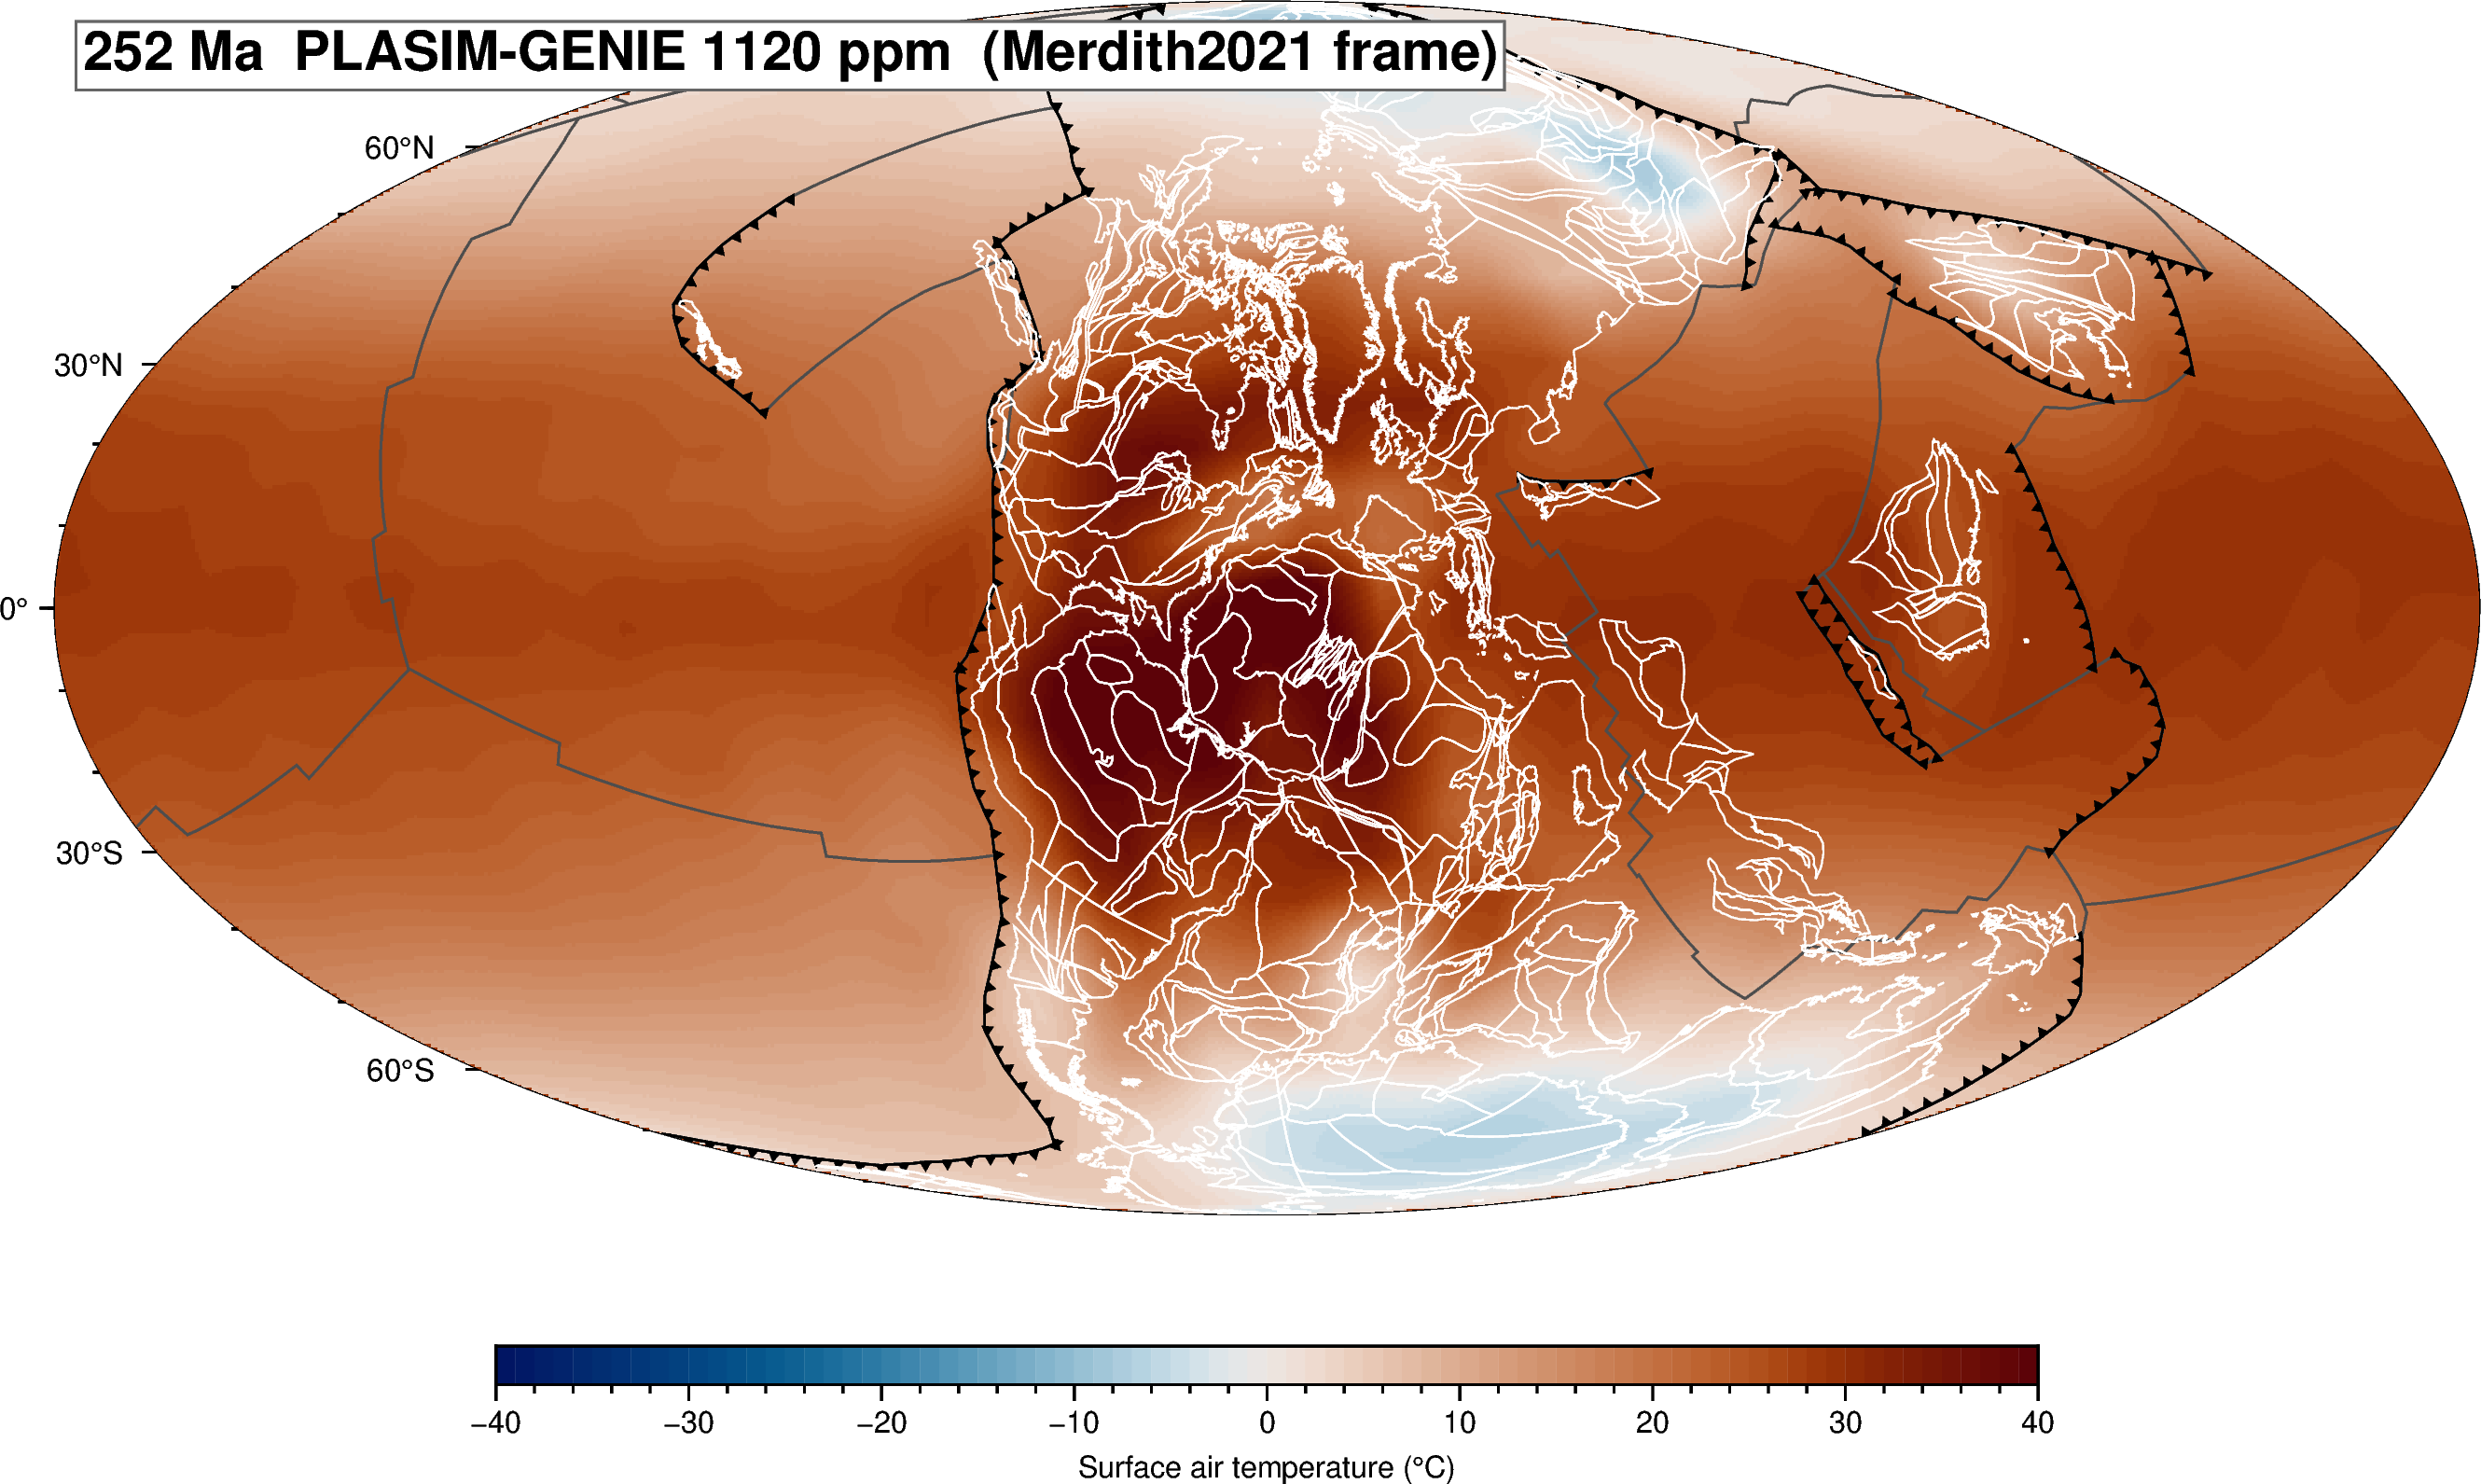

In [5]:
# Render the PLASIM-GENIE SAT field under the reconstructed plate boundaries.
# refine_for_plot resamples the coarse GCM grid for a clean Mollweide rim.
fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
pygmt.makecpt(cmap="vik", series=[SAT_RANGE[0], SAT_RANGE[1], 1], background="o")
fig.grdimage(refine_for_plot(sat_da), cmap=True)
fig.colorbar(frame="af+lSurface air temperature (°C)",
             position="JBC+w14c/0.35c+h+o0/1.2c")

# Continuous plate-boundary backbone first, then styled subduction teeth.
gplot.plot_all_topological_sections(fig, pen="0.6p,gray30")
gplot.plot_subduction_teeth(fig, color="black")

# Coastlines from the GPlately reconstruction (NOT the PLASIM-GENIE input
# geography). These are the Merdith2021 coastlines at 252 Ma; they should
# overlap the PLASIM-GENIE landsea_mask but expect cosmetic differences where
# the two paleogeography definitions disagree.
gplot.plot_coastlines(fig, pen="0.4p,white")

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  PLASIM-GENIE {CO2_PPM} ppm  ({MODEL_NAME} frame)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## 4. Cross-check — PLASIM-GENIE's own paleogeography next to the GPlately frame

Both `landsea_mask` (PLASIM-GENIE) and `coastlines` (GPlately) describe 252 Ma — but they're from different sources. If they disagree by more than coastal pixels, the overlay is internally inconsistent and the SAT-feature → continent mapping in the previous figure cannot be taken literally.

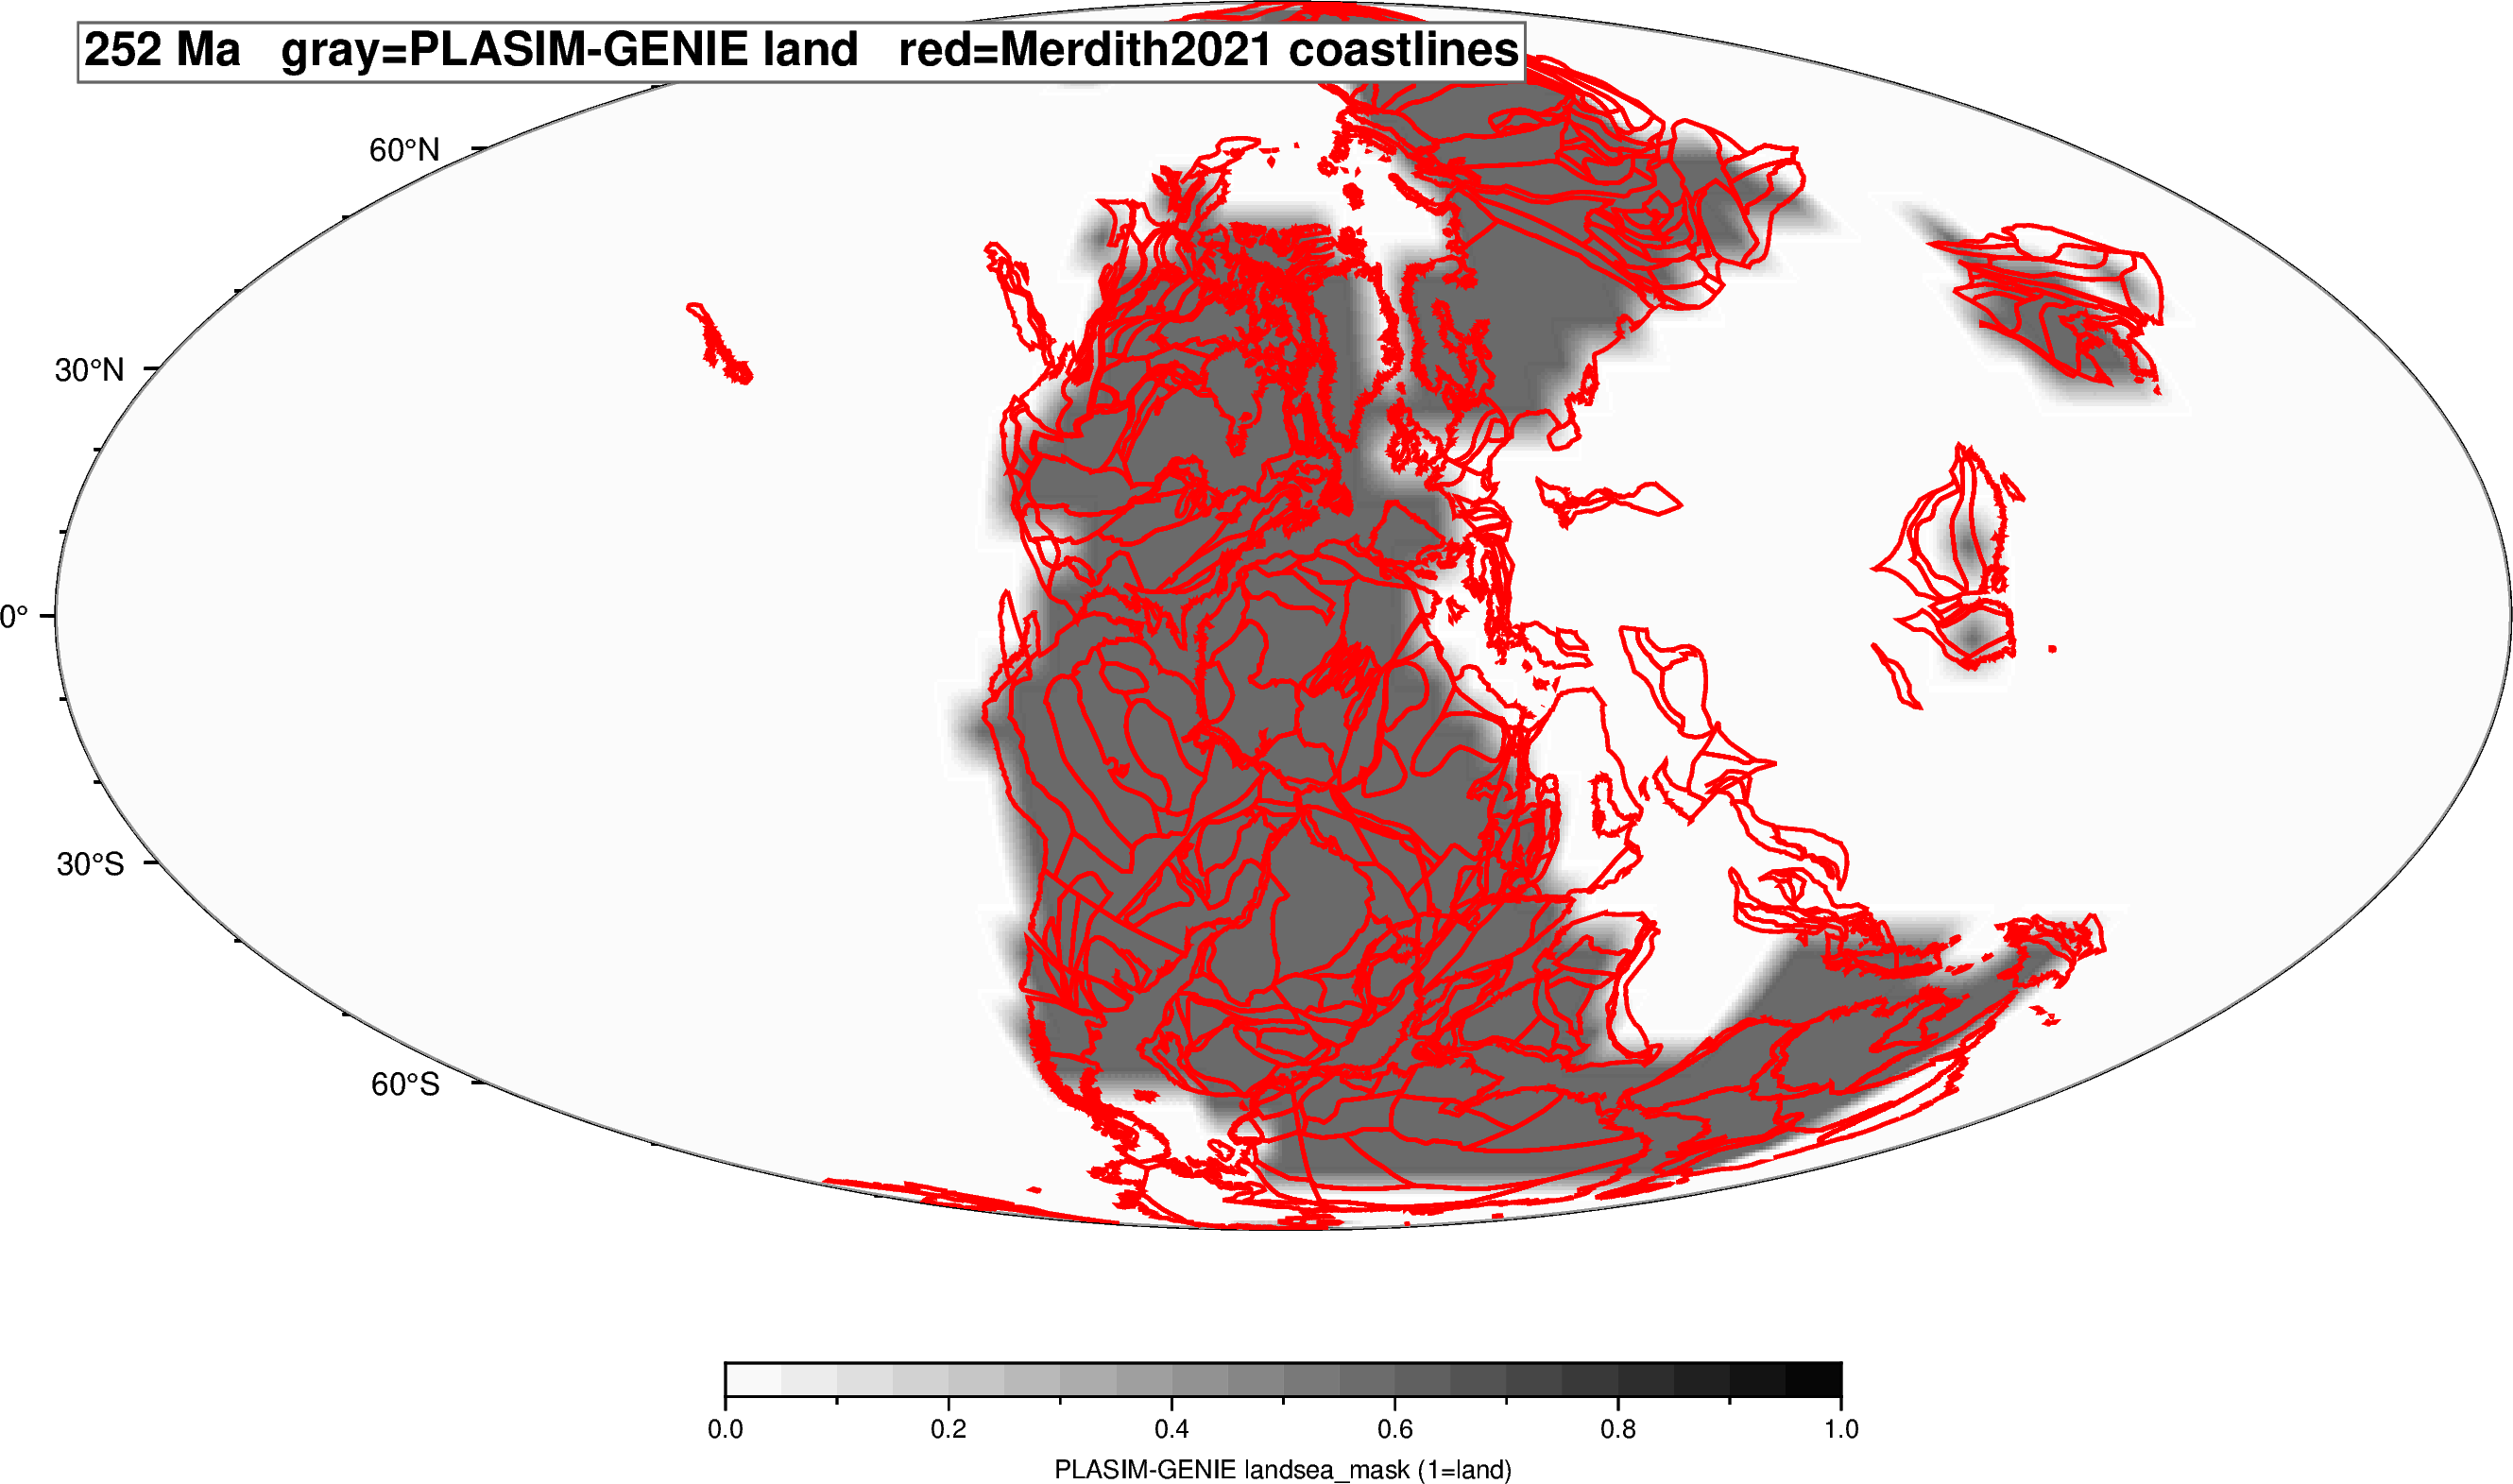

In [6]:
# Overlay check: PLASIM-GENIE land mask vs the reconstructed coastlines
lsmask = ds["landsea_mask"].sel(co2_ppm=CO2_PPM)
lsmask_da = (lsmask.assign_coords(longitude=((lsmask.longitude + 180) % 360 - 180))
                   .sortby("longitude")
                   .rename({"longitude": "lon", "latitude": "lat"}))

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
pygmt.makecpt(cmap="gray", series=[0, 1, 0.05], reverse=True)
fig.grdimage(refine_for_plot(lsmask_da), cmap=True, transparency=40)
fig.colorbar(frame="af+lPLASIM-GENIE landsea_mask (1=land)",
             position="JBC+w10c/0.3c+h+o0/1.2c")
gplot.plot_coastlines(fig, pen="1.0p,red")
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma   gray=PLASIM-GENIE land   red={MODEL_NAME} coastlines",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)

## What the figure shows

A Mollweide paleo-Earth at `RECONSTRUCTION_TIME` Ma with two overlays:

- **Gray, semi-transparent** — the PLASIM-GENIE landsea mask (`landsea_mask = 1` = land) interpolated onto the snapshot age.
- **Red lines** — `MODEL_NAME` (Merdith 2021) reconstructed coastlines at the same age.

Where the two overlays agree, gray land is located behind red coastlines — both models put landmass in the same place. Where they disagree:

- **Red coastlines with no gray underneath** — Merdith 2021 places a continent that the PLASIM-GENIE landsea grid does not see (typically because the GCM grid resolution is coarser, or because it uses a different geographic compilation entirely).
- **Gray land with no red coastline crossing it** — the PLASIM-GENIE run places land that Merdith 2021 does not (usually small land bridges or shelf areas).

The figure is a sanity check before driving any analysis: the PLASIM-GENIE surface-temperature field is only meaningful on the points where the model agrees the surface is land. Substantial disagreement here would prompt a re-projection step before extracting SAT onto Merdith 2021 paleo-positions.

## Extend this

- **Sweep the CO₂.** Change `CO2_PPM` to 17920 and re-run — the runaway end-Permian scenario; the polar regions become ice-free and the SAT contrast across the Pangean centre flattens.
- **Different paleogeography family.** The PLASIM-GENIE run's input geography is from the Merdith 2021 reconstruction. Swap `MODEL_NAME` to `Cao2024` or `Zahirovic2022` and the overlay-check panel will show by how much the two frames disagree.
- **Cross-reference T44.** T44 quantifies the CO₂-temperature sensitivity in GCM-internal coordinates. T43 places one of those snapshots on the GPlately reconstruction — closing the loop between climate-system response and paleogeographic context.

## References

- Holden, P.B., Edwards, N.R., Fraedrich, K., Kirk, E., Lunkeit, F. & Zhu, X. (2016). PLASIM–GENIE v1.0: a new intermediate complexity AOGCM. *Geoscientific Model Development* 9, 3347–3361. https://doi.org/10.5194/gmd-9-3347-2016
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., Young, A., Armistead, S.E., Cannon, J., Zahirovic, S. & Müller, R.D. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
- Müller, R.D. et al. (2022). A tectonic-rules-based mantle reference frame since 1 billion years ago. *Solid Earth* 13, 1127-1159.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3-10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Crameri, F. (2018). Scientific colour maps. *Zenodo*. https://doi.org/10.5281/zenodo.1243862